### Week 2: Exploratory Data Analysis - NextGenLearners Applicant Insights

**Student Name:** Aleeza Sheikh
    
**Dataset:** applicants_cleaned.csv

This notebook analyzes applicant data to understand domain popularity, application trends, acceptance rates, and university distribution to provide actionable insights for the NextGenLearners program.

In [1]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset
df = pd.read_csv('applicants_cleaned.csv', parse_dates = ['Application Date'])

In [3]:
# # data types + non-null counts per column
df.info()
# preview the first 5 rows
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Applicant Name    72 non-null     str           
 1   Email             72 non-null     str           
 2   Phone             72 non-null     str           
 3   Domain Applied    72 non-null     str           
 4   University        72 non-null     str           
 5   Application Date  66 non-null     datetime64[us]
 6   Status            72 non-null     str           
dtypes: datetime64[us](1), str(6)
memory usage: 4.1 KB


,Applicant Name,Email,Phone,Domain Applied,University,Application Date,Status
0,Adam Miller,bcherry@example.com,+12794198633x555,Web Development,Saunders Inc University,2026-07-19,Under Review
1,Amanda White,gmcgrath@example.org,9877971502,UI/UX Design,Oneal Inc University,2026-07-19,Under Review
2,Emily Torres,villanuevathomas@example.net,(620)3613890x4883,Data Science,"Petty, Clark And Irwin University",2026-07-19,Under Review
3,James Robinson,williamvalentine@example.org,4812129695,Web Development,"Ho, Garcia And Gutierrez University",2026-07-19,Rejected
4,Tina Newton,kharris@example.net,(795)2683086x8476,AI/ML,"Williams, Murphy And Lewis University",2026-07-19,Under Review


### Graph 1: Which Domain Received the Most Applications?

In [4]:
domain_counts = df['Domain Applied'].value_counts() 
print(domain_counts) 

Domain Applied
UI/UX Design       22
Data Science       16
Web Development    12
AI/ML              12
Mobile App         10
Name: count, dtype: int64


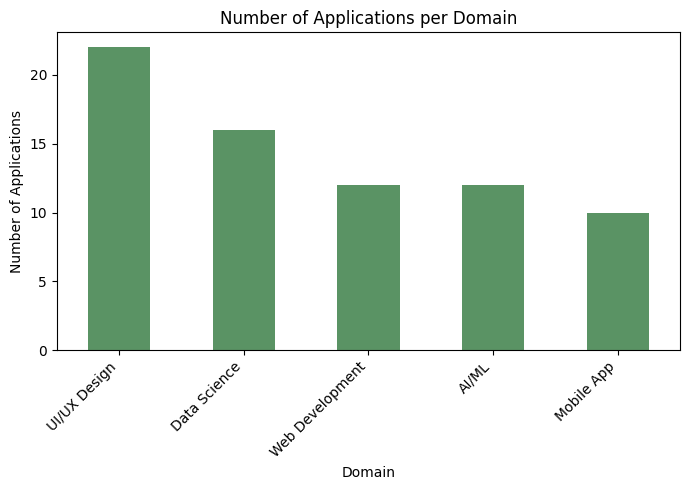

In [22]:
plt.figure(figsize=(7,5))
domain_counts.plot(kind='bar', color='#5A9364') 
plt.title('Number of Applications per Domain')
plt.xlabel('Domain')
plt.ylabel('Number of Applications')
plt.xticks(rotation=45, ha='right') 
plt.tight_layout() 
plt.show()

**Takeaway:** UI/UX Design received the highest number of applications (22), while Mobile App received the lowest (10).

 **plt.title('Number of Applications per Domain'):**
This sets the main title of the chart. It tells the reader what the graph is about.

 **plt.xlabel('Domain'):**
This labels the X-axis. It shows what categories are on the horizontal axis. Here it's

 **plt.xticks(rotation=45, ha='right'):**
This rotates the X-axis labels by 45 degrees to the right.
We do this so long labels like "Web Development" don't overlap and become unreadable.

### Graph 2: How Did Applications Trend Over Time?

In [24]:
# Group by month
df['Application Month'] = df['Application Date'].dt.to_period('M')
monthly_trend = df.groupby('Application Month').size()
print(monthly_trend)

Application Month
2026-07    66
Freq: M, dtype: int64


C:\Users\lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\plotting\_matplotlib\core.py:1613: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)


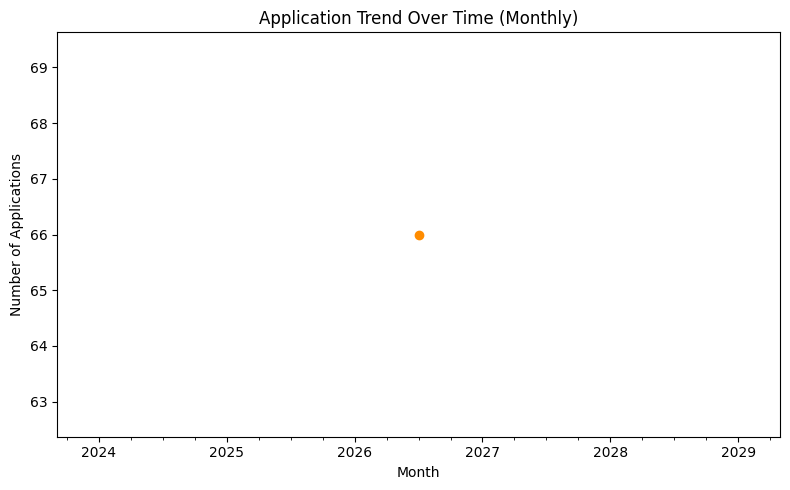

In [25]:
plt.figure(figsize=(8,5))
monthly_trend.plot(kind='line', marker='o', color='darkorange')
plt.title('Application Trend Over Time (Monthly)')
plt.xlabel('Month')
plt.ylabel('Number of Applications')
plt.tight_layout()
plt.show()

**Observation:** All 66 applications were submitted in July 2026.  
**Takeaway:** The dataset covers only 1 month, so no trend can be observed yet. More data is needed.

### Graph 3: What's the Acceptance Rate - Overall and Per Domain?

**Overall status breakdown:**

In [17]:
status_counts = df['Status'].value_counts()
print(status_counts)

Status
Rejected        29
Under Review    27
Selected        16
Name: count, dtype: int64


**Per-domain breakdown using pivot_table():**

In [18]:
status_by_domain = pd.pivot_table(df, index='Domain Applied', columns='Status', values='Applicant Name', aggfunc='count', fill_value=0)
print(status_by_domain)

Status           Rejected  Selected  Under Review
Domain Applied                                   
AI/ML                   4         5             3
Data Science            9         2             5
Mobile App              3         3             4
UI/UX Design            6         6            10
Web Development         7         0             5


**Calculate acceptance rate (percentage), not just raw counts:**

In [19]:
status_by_domain_pct = status_by_domain.div(status_by_domain.sum(axis=1),
axis=0) * 100
print(status_by_domain_pct.round(1))

Status           Rejected  Selected  Under Review
Domain Applied                                   
AI/ML                33.3      41.7          25.0
Data Science         56.2      12.5          31.2
Mobile App           30.0      30.0          40.0
UI/UX Design         27.3      27.3          45.5
Web Development      58.3       0.0          41.7


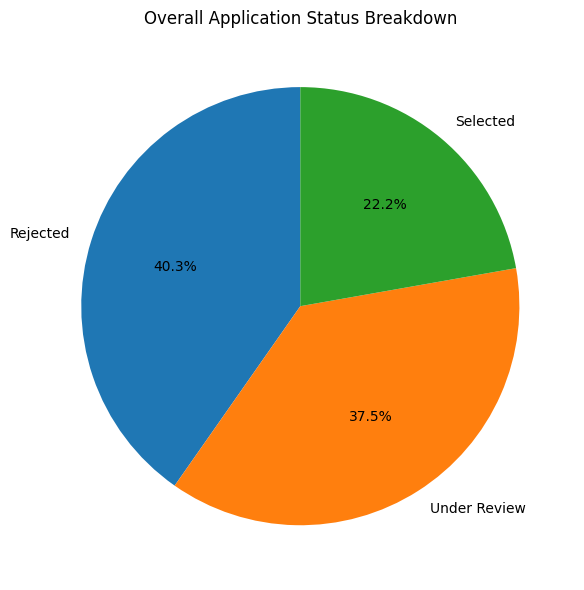

In [20]:
# Overall status - pie chart
plt.figure(figsize=(6,6))
status_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Overall Application Status Breakdown')
plt.ylabel('') # removes the default awkward y-label pie charts add
plt.tight_layout()
plt.show()

**Graph 3A: Overall Acceptance Rate**

**Observation:** Out of all applications, 40.3% are Rejected, 37.5% are Under Review, and only 22.2% are Selected.  
**Takeaway:** The overall selection rate is low. The hiring process is competitive and most candidates are either rejected or still pending.

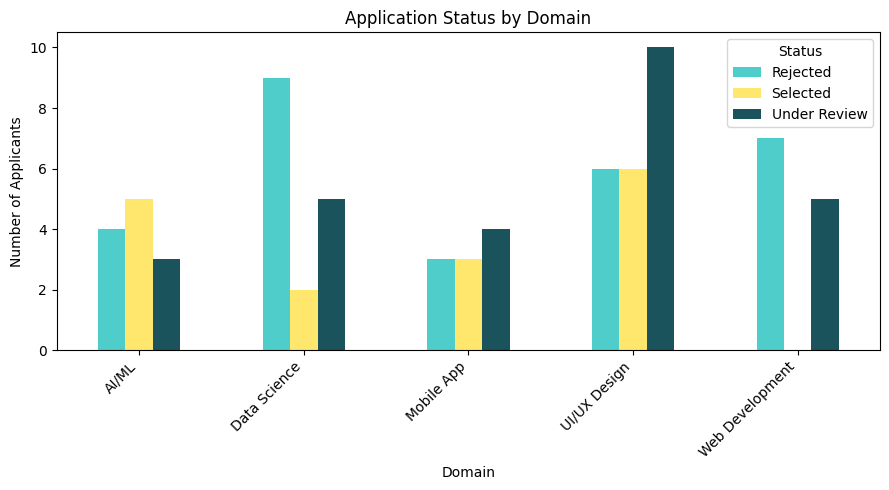

In [21]:
# Per-domain - grouped bar chart
status_by_domain.plot(kind='bar', figsize=(9,5), color = ('#4ECDCA', '#FFE66D', '#1A535C'))
plt.title('Application Status by Domain')
plt.xlabel('Domain')
plt.ylabel('Number of Applicants')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Status')
plt.tight_layout()
plt.show()

**Graph 3B: Acceptance Rate per Domain**

**Observation:** UI/UX Design has the highest number of Selected candidates (5) and also highest Under Review (9). Data Science has the most Rejections (9).  
**Takeaway:** UI/UX Design is performing best in selections, while Data Science needs review of its rejection criteria or applicant quality.

### Graph 4: Which Universities Sent the Most Applicants?

In [15]:
top_universities = df['University'].value_counts().head(10)
print(top_universities)

University
Not Specified                            4
Mit                                      3
Massachusetts Institute Of Technology    3
Saunders Inc University                  1
Oneal Inc University                     1
Petty, Clark And Irwin University        1
Ho, Garcia And Gutierrez University      1
Williams, Murphy And Lewis University    1
Duncan And Sons University               1
Barnes, Johnson And Molina University    1
Name: count, dtype: int64


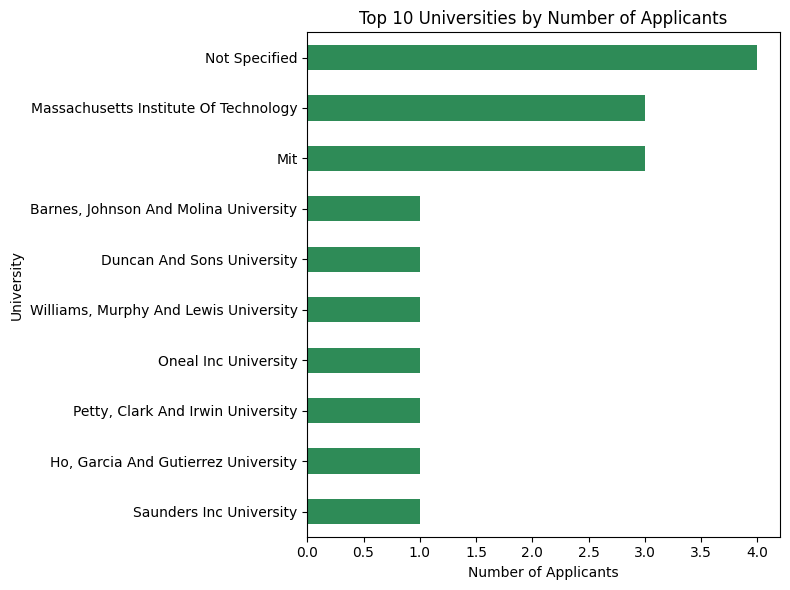

In [16]:
plt.figure(figsize=(8,6))
top_universities.sort_values().plot(kind='barh', color='seagreen')
plt.title('Top 10 Universities by Number of Applicants')
plt.xlabel('Number of Applicants')
plt.ylabel('University')
plt.tight_layout()
plt.show()

**Observation:** Most applicants did not specify their university. MIT have 3 applicants each.  
**Takeaway:** Outreach should focus on collecting complete university data for better insights.

### Bonus Chart: Domain Applications by Day of Week

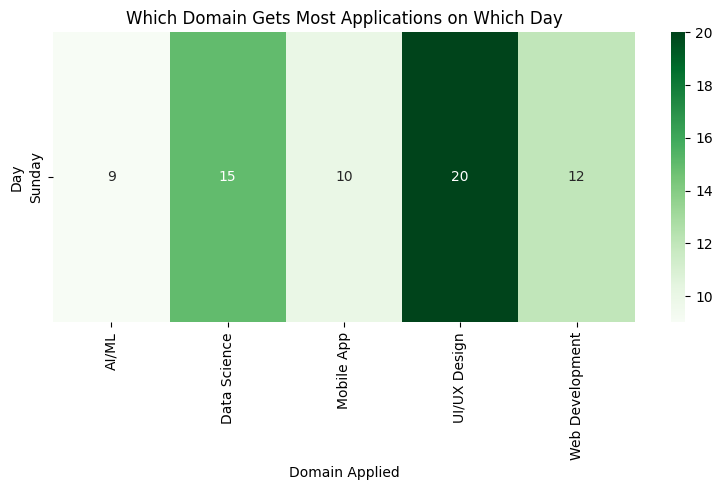

In [13]:
df['Day'] = df['Application Date'].dt.day_name()
heatmap_data = pd.crosstab(df['Day'], df['Domain Applied'])

plt.figure(figsize=(8,5))
sns.heatmap(heatmap_data, cmap='Greens', annot=True, fmt='d')
plt.title('Which Domain Gets Most Applications on Which Day')
plt.tight_layout()
plt.show()

**Why I chose this:**  
I chose this heatmap to see which day gets the most applications for each domain. This helps in understanding student behavior and planning better campaign timings.

**Observation:**  
From the heatmap, we can see that Sunday is the only day with application data. On Sunday, UI/UX Design received the highest 20 applications, followed by Data Science with 15. AI/ML had the lowest with 9 applications.

**Takeaway:**  
All applications in the current dataset were submitted on Sunday, with UI/UX Design being the most popular domain on that day. This suggests weekends are critical for application submissions.

In [26]:
## Key Insights

1. **Top Domain:** UI/UX Design is the most popular domain with 22 applications, followed by Data Science with 16. Mobile App has the lowest interest with only 10 applications.
2. **Lowest Domain: Mobile App has the fewest applications with 10, followed by Web Development with 12, suggesting a need for more outreach in these areas.
3. **Selection Rate:** Only 22.2% of total applicants were Selected. 40.3% were Rejected and 37.5% are still Under Review, showing a competitive process.
4. **Domain-wise Acceptance:** UI/UX Design has the highest number of Selected candidates. Data Science has the highest rejection rate with 9 rejections out of 16 applications.
5. **Monthly Data:** All 66 applications were submitted in July 2026. Only 1 month of data is available, so trends cannot be analyzed yet.
6. **Peak Submission Day:** Sunday is the peak day for applications. UI/UX Design received 20 applications on Sunday, indicating weekend activity is highest.
7. **University Gap:** Most applicants did not specify their university. This is a data quality issue that needs to be fixed.
8. **Top University:** Among applicants who specified, MIT has the highest representation with 3 applicants, making it the top named university.

SyntaxError: invalid syntax (3734797788.py, line 3)